Linear Regression - Train R²: 0.910, Test R²: 0.924
Optimal Ridge α: 100.00 (Test R²: 0.928)
✅ Alpha-sweep plot successfully saved.


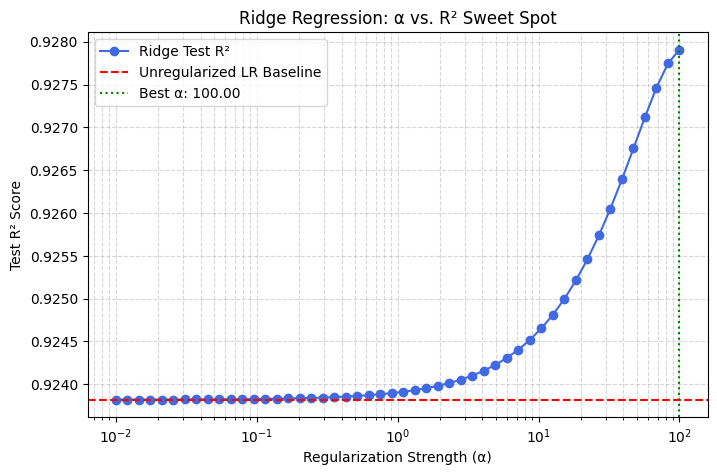

In [13]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. Load data
df = pd.read_csv('cp_data_demo.csv')

# Rows with a missing Formula / Temperature / Heat_Capacity can't be used
df = df.dropna(subset=['Formula', 'Temperature','Heat_Capacity']).reset_index(drop=True)

# 2. Featurize the formula (the file only contains raw text formulas)
MASS = {'Al': 26.982, 'B': 10.81, 'Ba': 137.327, 'Be': 9.012, 'Br': 79.904, 'C': 12.011,
        'Ca': 40.078, 'Cl': 35.45, 'Co': 58.933, 'Cr': 51.996, 'Cs': 132.905, 'Cu': 63.546,
        'F': 18.998, 'Fe': 55.845, 'Ga': 69.723, 'H': 1.008, 'Hf': 178.49, 'Hg': 200.59,
        'I': 126.904, 'K': 39.098, 'Li': 6.94, 'Mg': 24.305, 'Mn': 54.938, 'Mo': 95.95,
        'N': 14.007, 'Na': 22.990, 'Nb': 92.906, 'Ni': 58.693, 'O': 15.999, 'P': 30.974,
        'Pb': 207.2, 'Rb': 85.468, 'S': 32.06, 'Si': 28.085, 'Sr': 87.62, 'Ti': 47.867,
        'V': 50.942, 'W': 183.84, 'Zn': 65.38, 'Zr': 91.224}
EN = {'Al': 1.61, 'B': 2.04, 'Ba': 0.89, 'Be': 1.57, 'Br': 2.96, 'C': 2.55, 'Ca': 1.00,
      'Cl': 3.16, 'Co': 1.88, 'Cr': 1.66, 'Cs': 0.79, 'Cu': 1.90, 'F': 3.98, 'Fe': 1.83,
      'Ga': 1.81, 'H': 2.20, 'Hf': 1.30, 'Hg': 2.00, 'I': 2.66, 'K': 0.82, 'Li': 0.98,
      'Mg': 1.31, 'Mn': 1.55, 'Mo': 2.16, 'N': 3.04, 'Na': 0.93, 'Nb': 1.60, 'Ni': 1.91,
      'O': 3.44, 'P': 2.19, 'Pb': 2.33, 'Rb': 0.82, 'S': 2.58, 'Si': 1.90, 'Sr': 0.95,
      'Ti': 1.54, 'V': 1.63, 'W': 2.36, 'Zn': 1.65, 'Zr': 1.33}

def parse_formula(formula):
    """'Al2Be1O4' -> {'Al': 2.0, 'Be': 1.0, 'O': 4.0}"""
    comp = {}
    for el, n in re.findall(r'([A-Z][a-z]?)(\d*\.?\d*)', formula):
        comp[el] = comp.get(el, 0.0) + (float(n) if n else 1.0)
    return comp

def featurize(formula):
    comp = parse_formula(formula)
    n_atoms = sum(comp.values())
    feats = {'n_atoms': n_atoms,
             'n_elements': len(comp),
             'mean_mass': sum(MASS.get(e, np.nan) * n for e, n in comp.items()) / n_atoms,
             'mean_EN': sum(EN.get(e, np.nan) * n for e, n in comp.items()) / n_atoms}
    for e, n in comp.items():
        feats[f'frac_{e}'] = n / n_atoms
    return feats

feat_df = pd.DataFrame([featurize(f) for f in df['Formula']]).fillna(0.0)
feat_df = feat_df[sorted(feat_df.columns)]          # stable column order

X = pd.concat([feat_df, df[['Temperature']]], axis=1)   # Temperature is a FEATURE
y = df['Heat_Capacity']                                  # Heat capacity is the TARGET

# 3. Train/test split - grouped by formula so the same material
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['Formula']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 4. Unregularized Linear Regression baseline

lr = make_pipeline(StandardScaler(), LinearRegression())
lr.fit(X_train, y_train)
lr_train_r2 = r2_score(y_train, lr.predict(X_train))
lr_test_r2 = r2_score(y_test, lr.predict(X_test))
print(f"Linear Regression - Train R²: {lr_train_r2:.3f}, Test R²: {lr_test_r2:.3f}")

# 5. Ridge regression & alpha sweep (0.01 to 100)

alphas = np.logspace(-2, 2, 50)
ridge_test_scores = []

for alpha in alphas:
    ridge = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    ridge.fit(X_train, y_train)
    ridge_test_scores.append(r2_score(y_test, ridge.predict(X_test)))

best_alpha = alphas[np.argmax(ridge_test_scores)]
best_score = max(ridge_test_scores)
print(f"Optimal Ridge α: {best_alpha:.2f} (Test R²: {best_score:.3f})")

# 6. Plot the alpha sweep

plt.figure(figsize=(8, 5))
plt.plot(alphas, ridge_test_scores, marker='o', color='royalblue', label='Ridge Test R²')
plt.axhline(lr_test_r2, color='red', linestyle='--', label='Unregularized LR Baseline')
plt.axvline(best_alpha, color='green', linestyle=':', label=f'Best α: {best_alpha:.2f}')

plt.xscale('log')
plt.xlabel('Regularization Strength (α)')
plt.ylabel('Test R² Score')
plt.title('Ridge Regression: α vs. R² Sweet Spot')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.savefig('ridge_alpha_sweep.png', dpi=300, bbox_inches='tight')
print("✅ Alpha-sweep plot successfully saved.")
plt.show()

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [15]:
# --- 0. Sanity check: objects expected from earlier sessions (S25) ---
for name in ["X_train", "X_test", "y_train", "y_test", "lr", "best_alpha"]:
    if name not in globals():
        raise NameError(f"'{name}' is missing. Re-run the S25 cells first.")

# Keep feature names even if the data was scaled into a NumPy array
feature_names = (X_train.columns if hasattr(X_train, "columns")
                 else [f"x{i}" for i in range(X_train.shape[1])])

In [16]:
# --- 1. Train Lasso & extract zeroed features ---
# Option A (original): fixed alpha
# lasso = Lasso(alpha=1.0, random_state=42).fit(X_train, y_train)
# Option B (recommended): tune alpha via cross-validation
lasso = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_train, y_train)
lasso_preds = lasso.predict(X_test)

zeroed_features = np.array(feature_names)[lasso.coef_ == 0]
print(f"Lasso (alpha={lasso.alpha_:.4f}) forced {len(zeroed_features)} features to exactly 0.")
print("Sample of dropped features:", list(zeroed_features[:5]))

Lasso (alpha=7.5731) forced 42 features to exactly 0.
Sample of dropped features: ['frac_Al', 'frac_B', 'frac_Ba', 'frac_Be', 'frac_Br']


In [17]:
# --- 2. Train ElasticNet ---
# Original: ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
elastic = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
                       cv=5, random_state=42, max_iter=10000).fit(X_train, y_train)
elastic_preds = elastic.predict(X_test)
print(f"ElasticNet best alpha={elastic.alpha_:.4f}, l1_ratio={elastic.l1_ratio_}")


ElasticNet best alpha=7.5731, l1_ratio=1.0


In [18]:
# --- 3. Evaluation helper ---
def evaluate_model(y_true, y_pred):
    return {
        "R²": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

In [19]:
# --- 4. 4-model comparison table ---
# lr and best_alpha come from Session S25
ridge_best = Ridge(alpha=best_alpha).fit(X_train, y_train)   # needs the Ridge import

results = pd.DataFrame({
    "Unregularized LR": evaluate_model(y_test, lr.predict(X_test)),
    "Ridge (L2)":       evaluate_model(y_test, ridge_best.predict(X_test)),
    "Lasso (L1)":       evaluate_model(y_test, lasso_preds),
    "ElasticNet":       evaluate_model(y_test, elastic_preds),
}).T

print("\n--- 4-Model Evaluation Metrics ---")
try:
    display(results)      # Jupyter
except NameError:
    print(results)        # plain Python

# --- Save the deliverable ---
results.to_csv("regularization_comparison_s26.csv")
print("✅ 4-model comparison table successfully saved.")


--- 4-Model Evaluation Metrics ---


,R²,RMSE,MAE
Unregularized LR,0.923820,21.826064,15.009205
Ridge (L2),0.917973,22.648182,15.157836
Lasso (L1),0.899018,25.129109,17.207660
ElasticNet,0.899018,25.129109,17.207660


✅ 4-model comparison table successfully saved.
